<a href="https://colab.research.google.com/github/SydneySmoke/BME3053C-Spring-2025/blob/main/Homework_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft
from scipy.signal import find_peaks

In [2]:
def generate_ecg_data(duration, sampling_rate=250):
    def generate_ecg_pulse(duration, sampling_rate):
        t = np.linspace(0, duration, int(duration * sampling_rate), endpoint=False)
        # P wave
        p_wave = 0.15 * np.sin(2 * np.pi * 1.5 * t) * np.exp(-((t - 0.1) ** 2) / 0.005)
        # QRS complex
        qrs_complex = np.zeros_like(t)
        qrs_complex[(t > 0.2) & (t < 0.25)] = -0.3
        qrs_complex[(t > 0.25) & (t < 0.3)] = 1.0
        qrs_complex[(t > 0.3) & (t < 0.35)] = -0.2
        # T wave
        t_wave = 0.3 * np.sin(2 * np.pi * 0.75 * (t - 0.45)) * np.exp(-((t - 0.45) ** 2) / 0.015)
        # Combine all components
        pulse = p_wave + qrs_complex + t_wave
        # Add high-frequency noise to the pulse
        high_freq_noise = 0.05 * np.sin(2 * np.pi * 50 * t)
        pulse += high_freq_noise
        return pulse


    # Generate a single ECG pulse
    single_pulse = generate_ecg_pulse(0.8, sampling_rate)


    # Repeat the pulse to create a longer ECG signal
    num_pulses = int(duration / 0.8)
    ecg_data = np.tile(single_pulse, num_pulses)


    # Add more noise to make it more realistic
    noise = np.random.normal(0, 0.05, len(ecg_data))  # Increased noise amplitude
    ecg_data += noise


    # Add baseline wander
    t = np.linspace(0, duration, len(ecg_data), endpoint=False)
    baseline_wander = 0.1 * np.sin(2 * np.pi * 0.1 * t)
    ecg_data += baseline_wander


    # Add power line interference
    power_line_interference = 0.05 * np.sin(2 * np.pi * 60 * t)  # 60 Hz interference
    ecg_data += power_line_interference


    # Ensure the length of ecg_data matches the desired duration
    ecg_data = ecg_data[:int(duration * sampling_rate)]


    return ecg_data


ecg_data = generate_ecg_data(10, 250)
def generate_ecg_data(duration, sampling_rate=250):
    def generate_ecg_pulse(duration, sampling_rate):
        t = np.linspace(0, duration, int(duration * sampling_rate), endpoint=False)
        # P wave
        p_wave = 0.15 * np.sin(2 * np.pi * 1.5 * t) * np.exp(-((t - 0.1) ** 2) / 0.005)
        # QRS complex
        qrs_complex = np.zeros_like(t)
        qrs_complex[(t > 0.2) & (t < 0.25)] = -0.3
        qrs_complex[(t > 0.25) & (t < 0.3)] = 1.0
        qrs_complex[(t > 0.3) & (t < 0.35)] = -0.2
        # T wave
        t_wave = 0.3 * np.sin(2 * np.pi * 0.75 * (t - 0.45)) * np.exp(-((t - 0.45) ** 2) / 0.015)
        # Combine all components
        pulse = p_wave + qrs_complex + t_wave
        # Add high-frequency noise to the pulse
        high_freq_noise = 0.05 * np.sin(2 * np.pi * 50 * t)
        pulse += high_freq_noise
        return pulse

    # Generate a single ECG pulse
    single_pulse = generate_ecg_pulse(0.8, sampling_rate)

    # Repeat the pulse to create a longer ECG signal
    num_pulses = int(duration / 0.8)
    ecg_data = np.tile(single_pulse, num_pulses)

    # Add more noise to make it more realistic
    noise = np.random.normal(0, 0.05, len(ecg_data))  # Increased noise amplitude
    ecg_data += noise

    # Add baseline wander
    t = np.linspace(0, duration, len(ecg_data), endpoint=False)
    baseline_wander = 0.1 * np.sin(2 * np.pi * 0.1 * t)
    ecg_data += baseline_wander

    # Add power line interference
    power_line_interference = 0.05 * np.sin(2 * np.pi * 60 * t)  # 60 Hz interference
    ecg_data += power_line_interference

    # Ensure the length of ecg_data matches the desired duration
    ecg_data = ecg_data[:int(duration * sampling_rate)]

    return ecg_data

ecg_data = generate_ecg_data(10, 250)

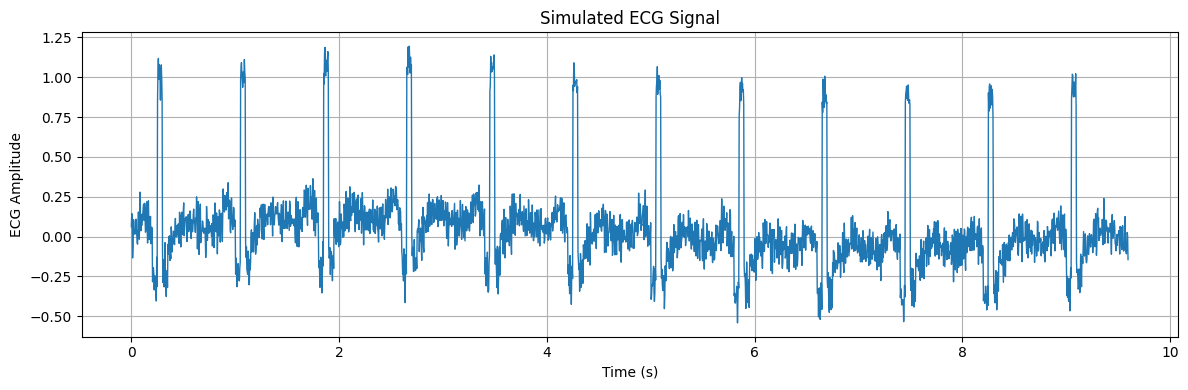

In [3]:
def generate_ecg_data(duration, sampling_rate=250):
    def generate_ecg_pulse(duration, sampling_rate):
        t = np.linspace(0, duration, int(duration * sampling_rate), endpoint=False)
        # P wave
        p_wave = 0.15 * np.sin(2 * np.pi * 1.5 * t) * np.exp(-((t - 0.1) ** 2) / 0.005)
        # QRS complex
        qrs_complex = np.zeros_like(t)
        qrs_complex[(t > 0.2) & (t < 0.25)] = -0.3
        qrs_complex[(t > 0.25) & (t < 0.3)] = 1.0
        qrs_complex[(t > 0.3) & (t < 0.35)] = -0.2
        # T wave
        t_wave = 0.3 * np.sin(2 * np.pi * 0.75 * (t - 0.45)) * np.exp(-((t - 0.45) ** 2) / 0.015)
        # Combine all components
        pulse = p_wave + qrs_complex + t_wave
        # Add high-frequency noise to the pulse
        high_freq_noise = 0.05 * np.sin(2 * np.pi * 50 * t)
        pulse += high_freq_noise
        return pulse

    # Generate a single ECG pulse
    single_pulse = generate_ecg_pulse(0.8, sampling_rate)

    # Repeat the pulse to create a longer ECG signal
    num_pulses = int(duration / 0.8)
    ecg_data = np.tile(single_pulse, num_pulses)

    # Add more noise to make it more realistic
    noise = np.random.normal(0, 0.05, len(ecg_data))
    ecg_data += noise

    # Add baseline wander
    t = np.linspace(0, duration, len(ecg_data), endpoint=False)
    baseline_wander = 0.1 * np.sin(2 * np.pi * 0.1 * t)
    ecg_data += baseline_wander

    # Add power line interference
    power_line_interference = 0.05 * np.sin(2 * np.pi * 60 * t)
    ecg_data += power_line_interference

    # Trim to exact length
    ecg_data = ecg_data[:int(duration * sampling_rate)]

    return ecg_data

# Parameters
duration = 10  # seconds
sampling_rate = 250  # Hz

# Generate ECG data
ecg_data = generate_ecg_data(duration, sampling_rate)

# Create time axis
time = np.arange(len(ecg_data)) / sampling_rate

# Plotting
plt.figure(figsize=(12, 4))
plt.plot(time, ecg_data, linewidth=1)
plt.title("Simulated ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("ECG Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

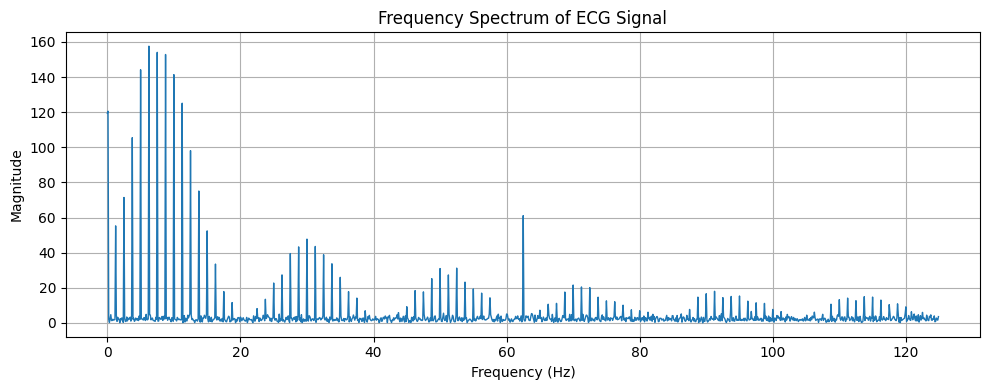

In [4]:
ecg_fft = np.fft.fft(ecg_data)
fft_magnitude = np.abs(ecg_fft)

# Generate frequency bins
frequencies = np.fft.fftfreq(len(ecg_data), d=1/sampling_rate)

# Only keep the positive half of the spectrum
half_n = len(frequencies) // 2
frequencies = frequencies[:half_n]
fft_magnitude = fft_magnitude[:half_n]

# Plotting the Fourier Transform
plt.figure(figsize=(10, 4))
plt.plot(frequencies, fft_magnitude, linewidth=1)
plt.title("Frequency Spectrum of ECG Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

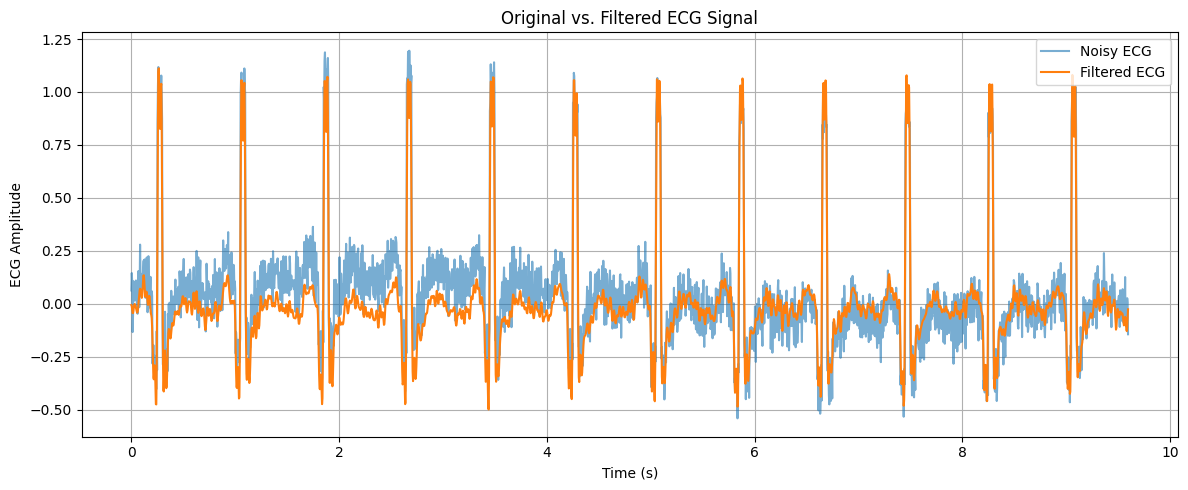

In [5]:
# Recompute the full FFT for filtering
ecg_fft_full = np.fft.fft(ecg_data)
frequencies_full = np.fft.fftfreq(len(ecg_data), d=1/sampling_rate)

# Create bandpass filter mask (0.5 Hz to 40 Hz)
bandpass_mask = (np.abs(frequencies_full) >= 0.5) & (np.abs(frequencies_full) <= 40)

# Apply the mask to the FFT
filtered_fft = ecg_fft_full * bandpass_mask

# Reconstruct the filtered signal using the inverse FFT
filtered_ecg = np.fft.ifft(filtered_fft)
filtered_ecg = np.real(filtered_ecg)  # Remove small imaginary part due to numerical error

# Plot the original vs. filtered ECG signal
plt.figure(figsize=(12, 5))
plt.plot(time, ecg_data, label="Noisy ECG", alpha=0.6)
plt.plot(time, filtered_ecg, label="Filtered ECG", linewidth=1.5)
plt.title("Original vs. Filtered ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("ECG Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

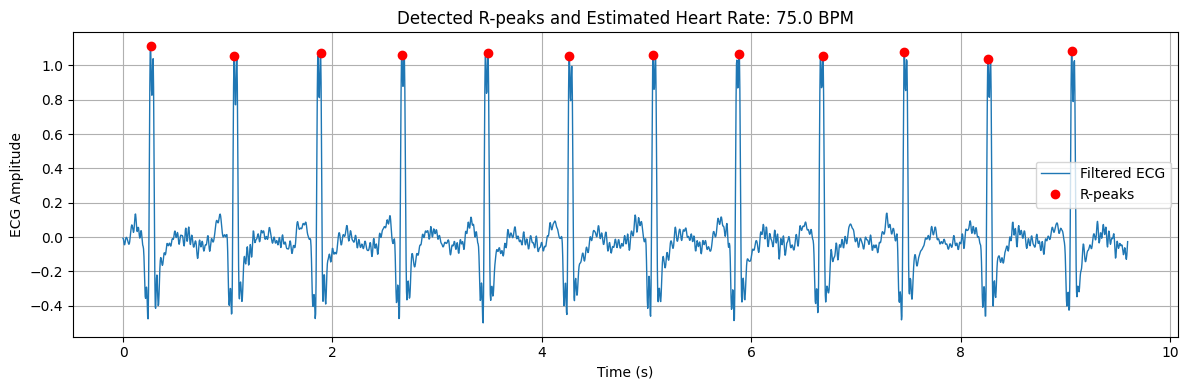

Estimated Heart Rate: 75.0 BPM


In [6]:
# Detect R-peaks in the filtered ECG
# Height and distance thresholds can be tuned depending on your signal
peaks, _ = find_peaks(filtered_ecg, height=0.5, distance=0.3 * sampling_rate)

# Calculate time differences between successive R-peaks
peak_times = time[peaks]
rr_intervals = np.diff(peak_times)  # in seconds

# Compute heart rate (BPM = 60 / avg RR interval)
average_rr = np.mean(rr_intervals)
heart_rate_bpm = 60 / average_rr

# Plot filtered ECG with detected R-peaks
plt.figure(figsize=(12, 4))
plt.plot(time, filtered_ecg, label="Filtered ECG", linewidth=1)
plt.plot(peak_times, filtered_ecg[peaks], "ro", label="R-peaks")
plt.title(f"Detected R-peaks and Estimated Heart Rate: {heart_rate_bpm:.1f} BPM")
plt.xlabel("Time (s)")
plt.ylabel("ECG Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print heart rate
print(f"Estimated Heart Rate: {heart_rate_bpm:.1f} BPM")

In this project, I generated a synthetic ECG signal and used signal processing to analyze it. After plotting the data, I applied a Fourier Transform to further disect its frequency components and identify noise. Next, a bandpass filter (0.5–40 Hz) was applied in the frequency domain to remove baseline drift and high-frequency interference. Then the refined signal was reconstructed via the inverse Fourier transform. For the final part, I used peak detection on the filtered ECG, and calculated the average heart rate, showing how Fourier analysis and filtering can extract meaningful physiological information from noisy signals.